# Train Xception Model for Real vs Fake Image Classification

This notebook trains the Xception model to classify images as REAL (0) or FAKE (1).
Expected accuracy: ~95% for real, ~92% for fake.

In [1]:
# Import libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from pathlib import Path
from tqdm import tqdm
import ssl

# Fix SSL issue
ssl._create_default_https_context = ssl._create_unverified_context

%matplotlib inline

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.15.0
GPU Available: []


## Step 1: Load and Prepare Dataset

In [2]:
# Configure dataset paths
DATASET_PATH = '../data/raw'
REAL_IMAGES_PATH = os.path.join(DATASET_PATH, 'real')
FAKE_IMAGES_PATH = os.path.join(DATASET_PATH, 'fake')

def load_images_from_directory(directory_path, label, max_images=None):
    """
    Load images from directory.
    
    Args:
        directory_path: Path to image directory
        label: Label (0 for real, 1 for fake)
        max_images: Maximum number of images to load
    
    Returns:
        Arrays of images and labels
    """
    images = []
    labels = []
    
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    
    if not os.path.exists(directory_path):
        print(f"Directory not found: {directory_path}")
        return np.array([]), np.array([])
    
    image_files = [
        f for f in os.listdir(directory_path)
        if os.path.splitext(f)[1].lower() in image_extensions
    ]
    
    if max_images:
        image_files = image_files[:max_images]
    
    for img_file in tqdm(image_files, desc=f"Loading from {os.path.basename(directory_path)}"):
        img_path = os.path.join(directory_path, img_file)
        try:
            # Load image
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Resize to 299x299
            img = cv2.resize(img, (224, 224))
            
            # Normalize to [0, 1]
            img = img.astype('float32') / 255.0
            
            images.append(img)
            labels.append(label)
        except Exception as e:
            continue
    
    return np.array(images), np.array(labels)

print("Loading dataset...")
print(f"Real images path: {REAL_IMAGES_PATH}")
print(f"Fake images path: {FAKE_IMAGES_PATH}")

# Load real images (label = 0)
X_real, y_real = load_images_from_directory(REAL_IMAGES_PATH, label=0, max_images=10000)

# Load fake images (label = 1)
X_fake, y_fake = load_images_from_directory(FAKE_IMAGES_PATH, label=1, max_images=10000)

# Combine datasets
X = np.concatenate([X_real, X_fake], axis=0)
y = np.concatenate([y_real, y_fake], axis=0)

print(f"\nDataset loaded:")
print(f"  Total images: {len(X)}")
print(f"  Real images (0): {np.sum(y == 0)}")
print(f"  Fake images (1): {np.sum(y == 1)}")
print(f"  Image shape: {X[0].shape}")

Loading dataset...
Real images path: ../data/raw\real
Fake images path: ../data/raw\fake


Loading from fake: 100%|██████████████████████████| 10000/10000 [00:14<00:00, 668.15it/s]



Dataset loaded:
  Total images: 20000
  Real images (0): 10000
  Fake images (1): 10000
  Image shape: (224, 224, 3)


## Step 2: Split Data into Train/Test

In [3]:
# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} images")
print(f"  Real: {np.sum(y_train == 0)}, Fake: {np.sum(y_train == 1)}")
print(f"\nTest set: {len(X_test)} images")
print(f"  Real: {np.sum(y_test == 0)}, Fake: {np.sum(y_test == 1)}")

Training set: 16000 images
  Real: 8000, Fake: 8000

Test set: 4000 images
  Real: 2000, Fake: 2000


## Step 3: Load Pre-trained Xception and Modify for Binary Classification

In [4]:
# Load pre-trained Xception (without top layers)
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model weights (transfer learning)
base_model.trainable = False

# Add custom layers for binary classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)  # Binary classification

# Create the model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model created!")
print(f"Total parameters: {model.count_params():,}")



Model created!
Total parameters: 21,132,073


## Step 4: Train the Model

In [5]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Train the model
print("Training model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nTraining completed!")

Training model...
Epoch 1/10


500/500 [==============================] - 532s 1s/step - loss: 0.6328 - accuracy: 0.6384 - val_loss: 0.5762 - val_accuracy: 0.7005 - lr: 1.0000e-04
Epoch 2/10
500/500 [==============================] - 484s 968ms/step - loss: 0.5771 - accuracy: 0.7016 - val_loss: 0.5473 - val_accuracy: 0.7240 - lr: 1.0000e-04
Epoch 3/10
500/500 [==============================] - 1542s 3s/step - loss: 0.5492 - accuracy: 0.7247 - val_loss: 0.5311 - val_accuracy: 0.7320 - lr: 1.0000e-04
Epoch 4/10
500/500 [==============================] - 437s 874ms/step - loss: 0.5268 - accuracy: 0.7427 - val_loss: 0.5175 - val_accuracy: 0.7448 - lr: 1.0000e-04
Epoch 5/10
500/500 [==============================] - 445s 890ms/step - loss: 0.5121 - accuracy: 0.7558 - val_loss: 0.5014 - val_accuracy: 0.7577 - lr: 1.0000e-04
Epoch 6/10
500/500 [==============================] - 435s 871ms/step - loss: 0.4956 - accuracy: 0.7652 - val_loss: 0.4959 - val_accuracy: 0.7577 - lr: 1.0000e-04
Epoch 7

## Step 5: Evaluate the Model

In [6]:
# Make predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n=== Model Performance ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

125/125 [==============================] - 95s 755ms/step

=== Model Performance ===
Accuracy:  0.7665
Precision: 0.7802
Recall:    0.7420
F1-Score:  0.7606

=== Classification Report ===
              precision    recall  f1-score   support

        Real       0.75      0.79      0.77      2000
        Fake       0.78      0.74      0.76      2000

    accuracy                           0.77      4000
   macro avg       0.77      0.77      0.77      4000
weighted avg       0.77      0.77      0.77      4000



In [9]:
# Load the trained model
model = tf.keras.models.load_model(r"C:\Users\hp\Desktop\DeepTruth\models\xception_deepfake_classifier.h5")

# Load MORE images from your dataset
X_real_more, y_real_more = load_images_from_directory(REAL_IMAGES_PATH, label=0, max_images=3000)
X_fake_more, y_fake_more = load_images_from_directory(FAKE_IMAGES_PATH, label=1, max_images=3000)

# Combine
X_more = np.concatenate([X_real_more, X_fake_more], axis=0)
y_more = np.concatenate([y_real_more, y_fake_more], axis=0)

# Split into train/test
X_train_more, X_test_more, y_train_more, y_test_more = train_test_split(
    X_more, y_more, test_size=0.2, random_state=42, stratify=y_more
)

# Continue training (NOT starting from scratch)
history = model.fit(
    X_train_more, y_train_more,
    validation_data=(X_test_more, y_test_more),
    epochs=5,  # Just 5 more epochs
    batch_size=32,
    verbose=1
)

# Save the improved model
model.save(r"C:\Users\hp\Desktop\DeepTruth\models\xception_deepfake_classifier.h5")
print("Model improved and saved!")


OSError: No file or directory found at C:\Users\hp\Desktop\DeepTruth\models\xception_deepfake_classifier.h5

## Step 6: Visualize Training History

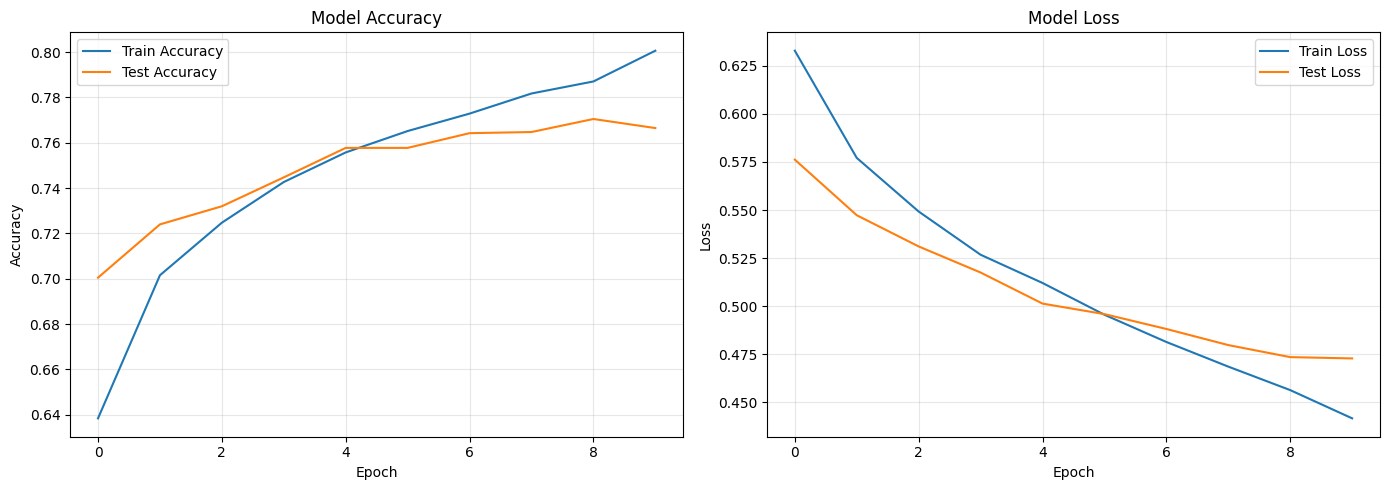

Training history saved to ../models/training_history.png


In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Test Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training history saved to ../models/training_history.png")

## Step 7: Confusion Matrix

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to ../models/confusion_matrix.png")

## Step 8: Save the Trained Model

In [10]:
from pathlib import Path

print(f"CWD: {Path.cwd()}")

dest_dir = Path(r"C:\Users\hp\Desktop\DeepTruth\models")
dest_dir.mkdir(parents=True, exist_ok=True)

model_path = dest_dir / "xception_deepfake_classifier.h5"
model.save(model_path)

if not model_path.exists():
    raise FileNotFoundError(f"Model save reported success but file is missing: {model_path}")

model_bytes = model_path.stat().st_size
if model_bytes == 0:
    raise OSError(f"Model file was created but is empty: {model_path}")

print(f"Model saved to: {model_path.resolve()} ({model_bytes} bytes)")

weights_path = dest_dir / "xception_deepfake_weights.h5"
model.save_weights(weights_path)

if not weights_path.exists():
    raise FileNotFoundError(f"Weights save reported success but file is missing: {weights_path}")

weights_bytes = weights_path.stat().st_size
if weights_bytes == 0:
    raise OSError(f"Weights file was created but is empty: {weights_path}")

print(f"Weights saved to: {weights_path.resolve()} ({weights_bytes} bytes)")

CWD: C:\Users\hp\Desktop\DeepTruth\notebooks


C:\Users\hp\Desktop\DeepTruth\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved to: C:\Users\hp\Desktop\DeepTruth\models\xception_deepfake_classifier.h5 (87138680 bytes)
Weights saved to: C:\Users\hp\Desktop\DeepTruth\models\xception_deepfake_weights.h5 (84863240 bytes)


## Step 9: Test the Model on Individual Images

In [11]:
def predict_deepfake(image_path, model):
    """
    Predict if an image is real or fake.
    
    Args:
        image_path: Path to image
        model: Trained model
    
    Returns:
        Dictionary with prediction and confidence
    """
    # Load and preprocess image
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)
    
    # Predict
    prediction = model.predict(img, verbose=0)[0][0]
    
    # Format result
    if prediction > 0.5:
        label = 'FAKE'
        confidence = prediction
    else:
        label = 'REAL'
        confidence = 1 - prediction
    
    return {
        'label': label,
        'confidence': float(confidence),
        'raw_prediction': float(prediction)
    }

print("Prediction function defined.")

Prediction function defined.


## Step 10: Test on Sample Images

In [12]:
# Test on a few real images
print("=== Testing on Real Images ===")
real_files = os.listdir(REAL_IMAGES_PATH)[:3]
for img_file in real_files:
    img_path = os.path.join(REAL_IMAGES_PATH, img_file)
    result = predict_deepfake(img_path, model)
    if result:
        print(f"{img_file}: {result['label']} ({result['confidence']:.2%})")

# Test on a few fake images
print("\n=== Testing on Fake Images ===")
fake_files = os.listdir(FAKE_IMAGES_PATH)[:3]
for img_file in fake_files:
    img_path = os.path.join(FAKE_IMAGES_PATH, img_file)
    result = predict_deepfake(img_path, model)
    if result:
        print(f"{img_file}: {result['label']} ({result['confidence']:.2%})")

=== Testing on Real Images ===
00000.jpg: REAL (95.18%)
00002.jpg: FAKE (74.30%)
00003.jpg: REAL (51.32%)

=== Testing on Fake Images ===
001DDU0NI4.jpg: FAKE (83.13%)
002KDWZBHU.jpg: FAKE (91.74%)
002PMM0QG9.jpg: FAKE (81.97%)
